# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

In [22]:
import yfinance as yf

# Escribe aquí tu código para descargar los datos de tus 3 activos elegidos
activos = ["CAT", "PEP", "XOM"]
precios = yf.download(
    activos,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=True
)
precios.head()

[*********************100%***********************]  3 of 3 completed


Price            Close                               High              \
Ticker             CAT         PEP        XOM         CAT         PEP   
Date                                                                    
2024-01-02  282.079834  156.347321  93.601601  285.867133  156.419659   
2024-01-03  273.975281  156.383484  94.388016  278.437141  158.417961   
2024-01-04  275.709930  155.045258  93.565018  277.752935  156.907932   
2024-01-05  278.437195  152.757599  93.848518  280.432028  155.135681   
2024-01-08  281.636627  152.911285  92.284821  282.051004  153.471892   

Price                         Low                               Open  \
Ticker            XOM         CAT         PEP        XOM         CAT   
Date                                                                   
2024-01-02  94.278281  280.769238  152.983650  92.220801  282.773687   
2024-01-03  94.753791  273.030890  156.157431  92.961499  277.916773   
2024-01-04  95.622497  273.483823  154.240509  93.318123  274.081303   
2024-01-05  94.552638  275.102857  151.509782  93.391301  275.854529   
2024-01-08  92.394555  274.881193  151.717719  90.437664  277.116947   

Price                               Volume                     
Ticker             PEP        XOM      CAT      PEP       XOM  
Date                                                           
2024-01-02  153.282042  92.284812  2433100  5743100  23483000  
2024-01-03  158.237121  93.519298  3043400  5588200  23490800  
2024-01-04  155.171847  95.174426  2995400  6283200  19395200  
2024-01-05  155.135681  94.342314  2684800  5252500  15827400  
2024-01-08  152.757571  92.111083  2369100  5735600  23370100

## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.

Primeras filas de precios reales:
Ticker             CAT         PEP        XOM
Date                                         
2024-01-02  282.079834  156.347321  93.601601
2024-01-03  273.975281  156.383484  94.388016
2024-01-04  275.709930  155.045258  93.565018
2024-01-05  278.437195  152.757599  93.848518
2024-01-08  281.636627  152.911285  92.284821


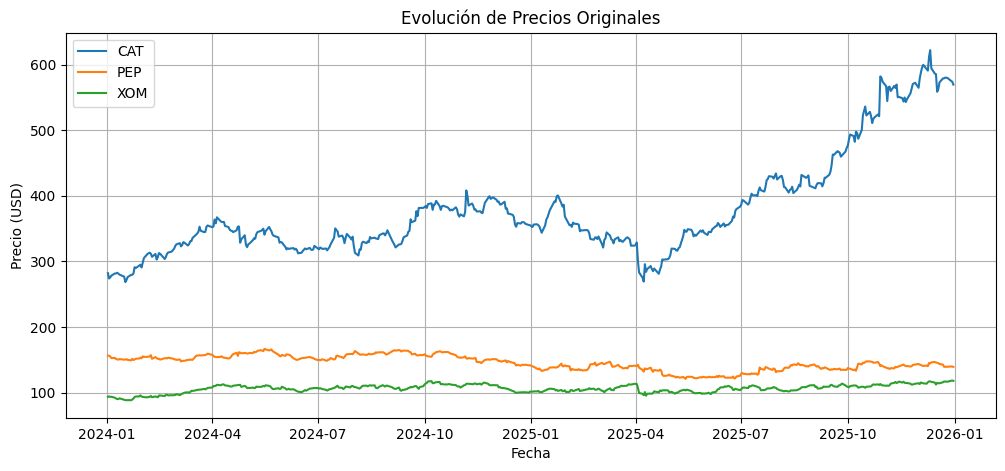

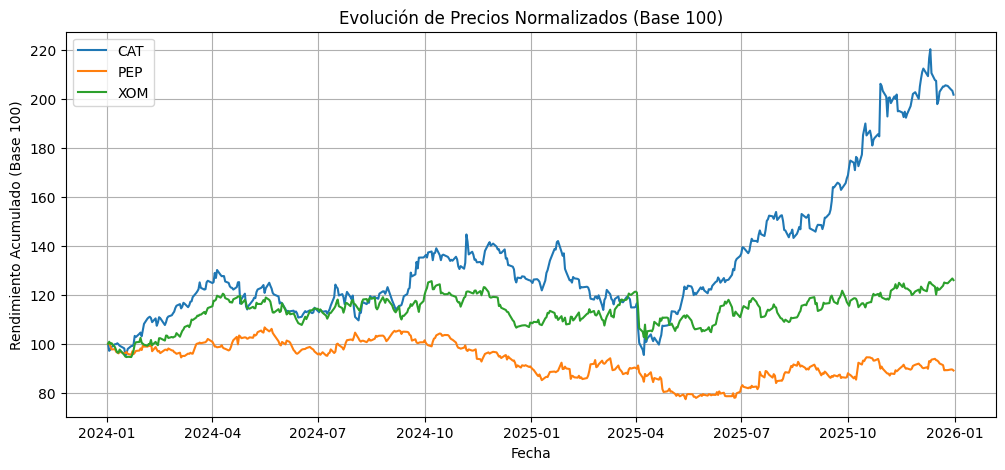

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extraer los precios de cierre de los datos descargados
precios_portafolio = precios['Close']
print("Primeras filas de precios reales:")
print(precios_portafolio.head())

# 2. Graficar precios originales
plt.figure(figsize=(12, 5))
for activo in precios_portafolio.columns:
    plt.plot(precios_portafolio.index, precios_portafolio[activo], label=activo)
plt.title('Evolución de Precios Originales')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)
plt.show()

# 3. Normalizar y graficar en base 100
precios_normalizados = (precios_portafolio / precios_portafolio.iloc[0]) * 100

plt.figure(figsize=(12, 5))
for activo in precios_normalizados.columns:
    plt.plot(precios_normalizados.index, precios_normalizados[activo], label=activo)
plt.title('Evolución de Precios Normalizados (Base 100)')
plt.xlabel('Fecha')
plt.ylabel('Rendimiento Acumulado (Base 100)')
plt.legend()
plt.grid(True)
plt.show()


Es más correcto porque nuestros activos tienen precios iniciales muy distintos (CAT $282 USD vs. XOM ~$$282 USD vs. XOM ~$93 USD). Si usáramos precios reales, un cambio de $10 USD parecería idéntico en el gráfico, pero porcentualmente representaría un impacto mucho mayor para XOM (10.7%) que para CAT (~3.5%). Al normalizarlos a Base 100, eliminamos la distorsión del precio nominal y medimos directamente el rendimiento porcentual acumulado de la inversión bajo una misma escala comparable.

2. Diferencia en el comportamiento visual observado:

Gráfico de Precios Originales: Visualmente parece que solo CAT tiene movimientos importantes debido a su alta escala de precio, mientras que las líneas de PEP y XOM se ven artificialmente planas y estables.
Gráfico Normalizado (Base 100): Aquí se aprecia la realidad del rendimiento. Identificamos claramente que CAT fue el líder con un retorno superior al +100% (superando los 200 puntos), XOM tuvo un crecimiento sólido y visible del +26% (cerrando en ~126), y PEP evidenció su tendencia bajista al caer a 89 (una pérdida del -11%), lo cual era imperceptible en el primer gráfico.

## 🔄 Paso 3: Cálculo y Distribución de Rendimientos

1. Calcula los rendimientos diarios de los activos y elimina los valores nulos (`NaN`).
2. Genera un **histograma* para el activo que consideres que haya sido el más volátil.
3. Diseña un **Boxplot** comparativo que muestre los rendimientos diarios de tus 3 activos simultáneamente.

### 💬 Pregunta de interpretación #2:
Observando el Boxplot y el Histograma:
- ¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?
- ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente de estas empresas?

Primeras filas de los rendimientos diarios:
Ticker           CAT       PEP       XOM
Date                                    
2024-01-03 -0.028731  0.000231  0.008402
2024-01-04  0.006331 -0.008557 -0.008719
2024-01-05  0.009892 -0.014755  0.003030
2024-01-08  0.011491  0.001006 -0.016662
2024-01-09  0.000137 -0.011472 -0.012386

El activo más volátil es: CAT (Desviación estándar: 0.0184)


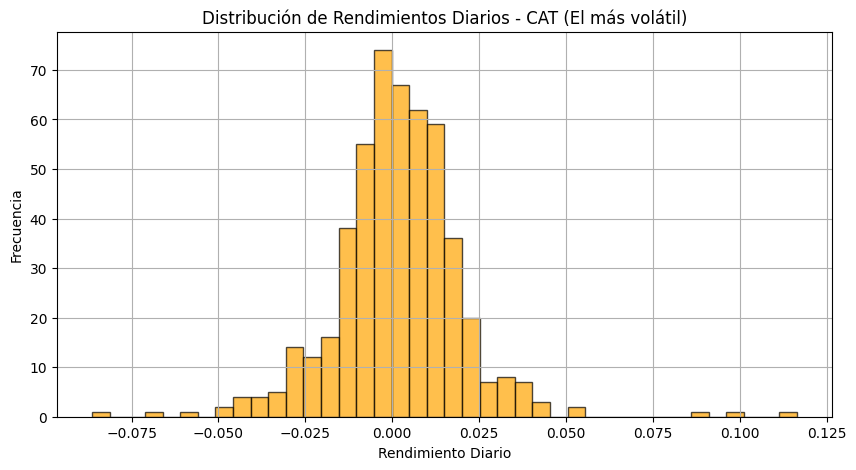

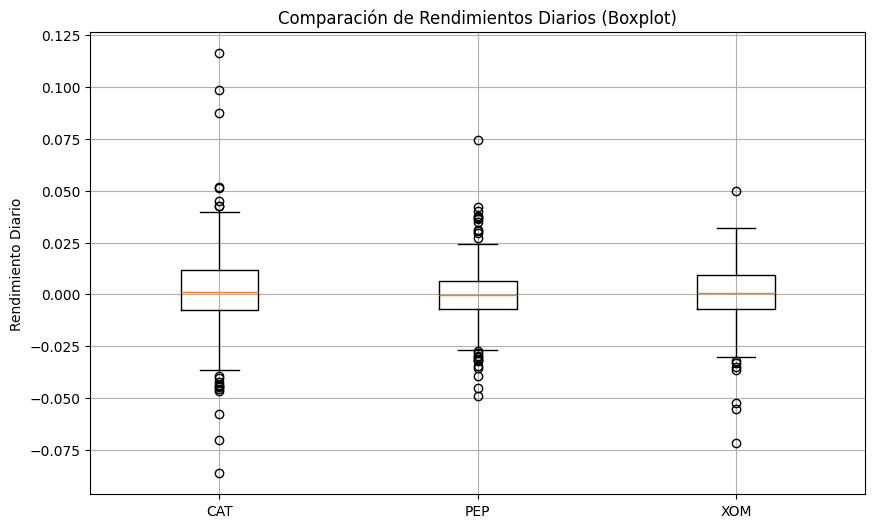

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calcular rendimientos diarios de los activos reales y eliminar nulos
rendimientos = precios_portafolio.pct_change().dropna()
print("Primeras filas de los rendimientos diarios:")
print(rendimientos.head())

# Identificar el activo más volátil utilizando la desviación estándar
volatilidad = rendimientos.std()
activo_mas_volatil = volatilidad.idxmax()
print(f"\nEl activo más volátil es: {activo_mas_volatil} (Desviación estándar: {volatilidad[activo_mas_volatil]:.4f})")

# 2. Histograma con el activo más volátil
plt.figure(figsize=(10, 5))
plt.hist(rendimientos[activo_mas_volatil], bins=40, edgecolor='black', alpha=0.7, color='orange')
plt.title(f'Distribución de Rendimientos Diarios - {activo_mas_volatil} (El más volátil)')
plt.xlabel('Rendimiento Diario')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

# 3. Boxplot comparativo de rendimientos de los 3 activos usando tick_labels
plt.figure(figsize=(10, 6))
plt.boxplot([rendimientos[col] for col in rendimientos.columns], tick_labels=rendimientos.columns)
plt.title('Comparación de Rendimientos Diarios (Boxplot)')
plt.ylabel('Rendimiento Diario')
plt.grid(True)
plt.show()

1. ¿Qué activo presenta la mayor dispersión y qué te dice esto sobre su riesgo?

El activo con mayor dispersión es CAT (Caterpillar), ya que muestra la caja más ancha y los bigotes más largos en el Boxplot, además de una distribución más extendida en el histograma. Esto me indica que CAT es la opción de mayor volatilidad y riesgo, con oscilaciones de precio diarias mucho más bruscas que las de PEP o XOM.

2. ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente?

Sí, identifico varios valores atípicos (outliers) representados por puntos aislados fuera de los bigotes en el Boxplot para las tres acciones.

En el contexto de la historia económica reciente, estos puntos representan días de volatilidad extrema causados por noticias de alto impacto, como la publicación de reportes trimestrales de ganancias, decisiones sorpresa de la Reserva Federal sobre tasas de interés, o shocks geopolíticos y de oferta que sacudieron los mercados de materias primas e industria.


## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?

Matriz de Correlación de Pearson:


Ticker,CAT,PEP,XOM
Ticker,,,
CAT,1.000000,0.033416,0.338713
PEP,0.033416,1.000000,0.149887
XOM,0.338713,0.149887,1.000000


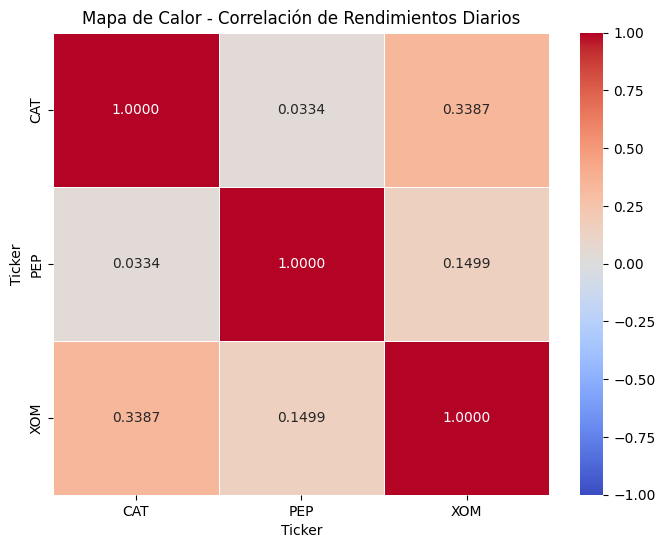

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcular matriz de correlación de Pearson
matriz_correlacion = rendimientos.corr()
print("Matriz de Correlación de Pearson:")
display(matriz_correlacion)

# 2. Dibujar el Heatmap utilizando Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.4f',
    linewidths=0.5
)
plt.title('Mapa de Calor - Correlación de Rendimientos Diarios')
plt.show()

1. ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos? No. La única relación moderada-débil es entre CAT y XOM (0.3387). Las demás son casi nulas: CAT y PEP (0.0334) y XOM y PEP (0.1499). Esto me indica que sus precios se mueven de manera muy independiente.

2. Si tuvieras que armar un portafolio de inversión buscando la diversificación, ¿qué par de activos elegirías y por qué? Elegiría CAT y PEP. Al tener la correlación más baja (0.0334), se mueven de forma totalmente independiente, lo que me permite usar el comportamiento estable y defensivo de PEP para amortiguar las fuertes caídas y el riesgo de CAT.

## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos.

In [32]:
# Generar resumen de estadísticas descriptivas (Media, Mediana, Desviación estándar, Mínimo y Máximo)

estadisticas_resumen = rendimientos.agg(['mean', 'median', 'std', 'min', 'max'])

# Renombrar los índices para una presentación más formal
estadisticas_resumen.index = ['Media', 'Mediana', 'Desviación Estándar', 'Mínimo', 'Máximo']

print("Resumen Estadístico Descriptivo de los Rendimientos Diarios:")
display(estadisticas_resumen)

Resumen Estadístico Descriptivo de los Rendimientos Diarios:


Ticker,CAT,PEP,XOM
Media,0.001570,-0.000154,0.000553
Mediana,0.001136,-0.000538,0.000583
Desviación Estándar,0.018367,0.012438,0.013455
Mínimo,-0.086356,-0.048854,-0.071956
Máximo,0.116346,0.074547,0.049916


CAT (Perfil de Crecimiento/Riesgo): Ha sido el motor de rendimiento de este portafolio con un excelente retorno promedio diario ($+0.157\%$$+0.157\%$) y un pico de ganancias del $11.63\%$$11.63\%$. No obstante, esto viene acompañado de la mayor volatilidad ($1.83\%$$1.83\%$) y caídas de hasta $-8.63\%$$-8.63\%$. Es ideal para una estrategia de crecimiento agresivo.

PEP (Perfil Defensivo/Estabilizador): Aunque ha tenido un periodo plano o ligeramente negativo, su baja volatilidad ($1.24\%$$1.24\%$) y caídas máximas controladas reafirman su rol como activo defensivo. Al tener una correlación casi nula con CAT ($0.033$$0.033$), es una pieza indispensable para amortiguar los golpes del mercado y estabilizar el portafolio.

XOM (Perfil Moderado): Ofrece un sano punto intermedio, aportando rendimientos promedio positivos con un riesgo moderado.

Recomendación: Sugerimos estructurar un portafolio combinando CAT para capturar el crecimiento económico y PEP como escudo de diversificación debido a su baja correlación mutua, logrando un balance óptimo que maximiza el rendimiento por cada unidad de riesgo asumida."*